# BinWaves example in Cantabria (Propagation)

**In this notebook**: 
<br><br>
Here is where the construction of the library of pre-run cases for all the monochromatic wave systems is made.
<br><br>
Steps:
- Generates wave conditions for all given frequencies and directions.
- Generates SWAN cases and runs them.
- Extracts SWAN cases and saves output.
- Plots the library for all the cases and some larger example ones.

## Generate computational bathymetry

In [1]:
import xarray as xr
bathy = -(
    xr.open_dataset("outputs/GEBCO_Duke_100m.nc")
    .rename({"cx": "lon", "cy": "lat"})
    .transpose("lat", "lon")
    .isel(lon=slice(0, None, 5), lat=slice(0, None, 5))  # This gives 500m resolution
    .sortby("lat", ascending=False)
    .elevation
    # .sortby("lat")
)
bathy

<xarray.DataArray 'elevation' (lat: 443, lon: 364)> Size: 1MB
array([[            nan, -6.80194969e+00, -6.56631083e+00, ...,
         1.83257012e+03,  1.84502895e+03,  1.85890320e+03],
       [            nan, -1.13743113e+01, -8.72984567e+00, ...,
         1.80585402e+03,  1.81989065e+03,  1.83333799e+03],
       [            nan, -1.27134870e+01, -1.04539205e+01, ...,
         1.77458375e+03,  1.79193151e+03,  1.80628927e+03],
       ...,
       [            nan,  1.00000000e+00,  1.00000000e+00, ...,
         3.22368471e+03,  3.22471126e+03,  3.22010700e+03],
       [            nan,  1.00000000e+00,  1.00000000e+00, ...,
         3.22843965e+03,  3.22775623e+03,  3.22197481e+03],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan]],
      shape=(443, 364))
Coordinates:
  * lon      (lon) float64 3kB 3.719e+05 3.724e+05 ... 5.529e+05 5.534e+05
  * lat      (lat) float64 4kB 4.073e+06 4.072e+06 ... 3.852e+06 3.852e+06
Attributes:
    standard_name:       height_above_mean_sea_level
    long_name:           Elevation relative to sea level
    units:               m
    grid_mapping:        crs
    sdn_parameter_urn:   SDN:P01::BATHHGHT
    sdn_parameter_name:  Sea floor height (above mean sea level) {bathymetric...
    sdn_uom_urn:         SDN:P06::ULAA
    sdn_uom_name:        Metres

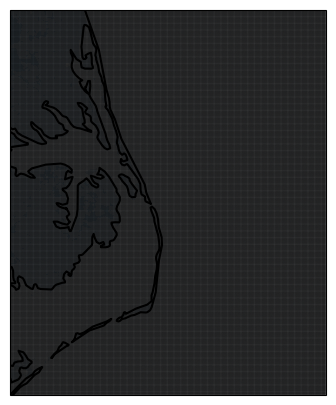

In [2]:
from utils.plotting import plot_selected_bathy

plot_selected_bathy(bathy=bathy)

In [3]:
from bluemath_tk.topo_bathy.swan_grid import generate_grid_parameters

fixed_parameters = generate_grid_parameters(bathy_data=bathy)
fixed_parameters

{'xpc': 371933,
 'ypc': 3851757,
 'alpc': 0,
 'xlenc': 181500,
 'ylenc': 221000,
 'mxc': 363,
 'myc': 442,
 'xpinp': np.float64(371933.1394073728),
 'ypinp': np.float64(3851757.252582026),
 'alpinp': 0,
 'mxinp': 363,
 'myinp': 442,
 'dxinp': np.float64(500.0),
 'dyinp': np.float64(500.0)}

## Create SWAN cases

In [4]:
from bluemath_tk.waves.binwaves import generate_swan_cases
from utils.wrapper import example_directions, example_frequencies

# Generate swan model parameters
example_directions = example_directions
swan_cases_df = (
    generate_swan_cases(
        directions_array=example_directions,
        frequencies_array=example_frequencies,
    )
    .astype(float)
    .to_dataframe()
    .reset_index()
)
swan_cases_df

,dir,freq,hs,tp,spr,gamma
0,7.5,0.035000,1.0,28.5714,2.0,50.0
1,7.5,0.038500,1.0,25.9740,2.0,50.0
2,7.5,0.042350,1.0,23.6128,2.0,50.0
3,7.5,0.046585,1.0,21.4661,2.0,50.0
4,7.5,0.051243,1.0,19.5147,2.0,50.0
...,...,...,...,...,...,...
691,352.5,0.344741,0.1,2.9007,2.0,50.0
692,352.5,0.379215,0.1,2.6370,2.0,50.0
693,352.5,0.417136,0.1,2.3973,2.0,50.0
694,352.5,0.458850,0.1,2.1794,2.0,50.0


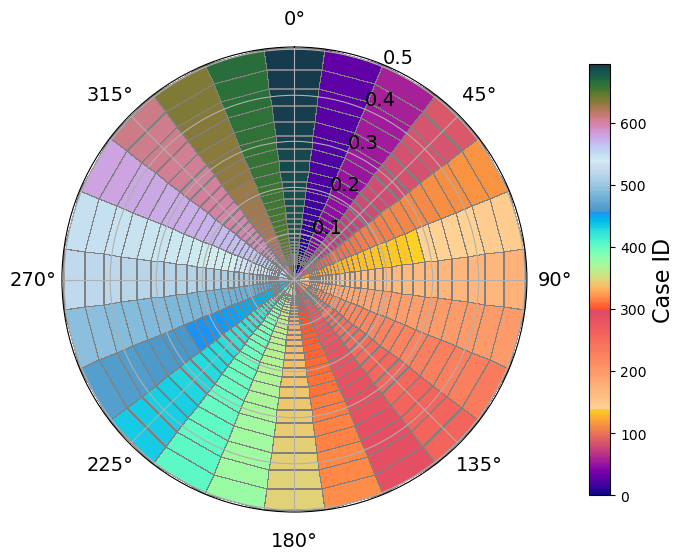

In [5]:
import numpy as np
from bluemath_tk.waves.binwaves import plot_selected_cases_grid

# Plot the cases grid

plot_selected_cases_grid(
    frequencies=np.array(example_frequencies),
    directions=np.array(example_directions),
    figsize=(8, 8),
)

## Build and run SWAN cases

In [6]:
import os
from utils.wrapper import BinWavesWrapper

# Define the input templates and output directory for the wrapper

templates_dir = os.path.join(os.getcwd(), "templates")
templates_name = ["INPUT"]
output_dir = os.path.join(os.getcwd(), "Duke2_cases")

# Create an instance of the SWAN model wrapper

swan_wrapper = BinWavesWrapper(
    templates_dir=templates_dir,
    templates_name=templates_name,
    metamodel_parameters=swan_cases_df.to_dict(orient="list"),
    fixed_parameters=fixed_parameters,
    output_dir=output_dir,
    depth_dataarray=bathy,
)

Original depth_dataarray shape: (443, 364)
Original lat values: [4072757.25258203 4072257.25258203 4071757.25258203 4071257.25258203
 4070757.25258203 4070257.25258203 4069757.25258203 4069257.25258203
 4068757.25258203 4068257.25258203 4067757.25258203 4067257.25258203
 4066757.25258203 4066257.25258203 4065757.25258203 4065257.25258203
 4064757.25258203 4064257.25258203 4063757.25258203 4063257.25258203
 4062757.25258203 4062257.25258203 4061757.25258203 4061257.25258203
 4060757.25258203 4060257.25258203 4059757.25258203 4059257.25258203
 4058757.25258203 4058257.25258203 4057757.25258203 4057257.25258203
 4056757.25258203 4056257.25258203 4055757.25258203 4055257.25258203
 4054757.25258203 4054257.25258203 4053757.25258203 4053257.25258203
 4052757.25258203 4052257.25258203 4051757.25258203 4051257.25258203
 4050757.25258203 4050257.25258203 4049757.25258203 4049257.25258203
 4048757.25258203 4048257.25258203 4047757.25258203 4047257.25258203
 4046757.25258203 4046257.25258203 4045

2025-05-19 19:24:02,352 - BinWavesWrapper - WARNING - Parameter dir is not in the default_parameters
2025-05-19 19:24:02,352 - BinWavesWrapper - WARNING - Parameter freq is not in the default_parameters
2025-05-19 19:24:02,353 - BinWavesWrapper - WARNING - Parameter hs is not in the default_parameters
2025-05-19 19:24:02,353 - BinWavesWrapper - WARNING - Parameter tp is not in the default_parameters
2025-05-19 19:24:02,353 - BinWavesWrapper - WARNING - Parameter spr is not in the default_parameters
2025-05-19 19:24:02,354 - BinWavesWrapper - WARNING - Parameter gamma is not in the default_parameters


In [7]:
swan_wrapper.locations

array([[ 371933.13940737, 4072757.25258203],
       [ 376933.13940737, 4072757.25258203],
       [ 381933.13940737, 4072757.25258203],
       ...,
       [ 470164.24      , 3956270.58      ],
       [ 474075.136     , 3901692.114     ],
       [ 458576.64      , 3874246.18      ]], shape=(1672, 2))

In [8]:
# Build the input files

swan_wrapper.build_cases(mode="one_by_one")
swan_cases_df.to_csv(os.path.join(output_dir, "swan_cases.csv"), index=False)

# Set the cases directories from the output directory
# Execute if the cases are already built

# swan_wrapper.set_cases_dirs_from_output_dir()

In [11]:
from utils.create_geojson import create_geojson   
locations_file = "/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/Duke2_cases/0000/locations.loc"
output_file = "/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/Duke2_cases/0000/locations_mesh1.geojson"
create_geojson(locations_file, output_file) 



In [12]:
# Run the model

swan_wrapper.run_cases_in_background(launcher="/software/geocean/swan/swan_serial.exe", num_workers=20)

In [27]:
import pandas as pd
pd.set_option('display.max_rows', None)  # Show all rows
swan_wrapper.monitor_cases()

,Case,Percentage
0,0000,100 %
1,0001,100 %
2,0002,100 %
3,0003,100 %
4,0004,100 %
5,0005,100 %
6,0006,100 %
7,0007,100 %
8,0008,100 %
9,0009,100 %


In [ ]:
# # Monitor running cases

# swan_wrapper.monitor_cases()

In [29]:
# Post-process the output files

cases_bulk_parameters = swan_wrapper.postprocess_cases()
cases_bulk_parameters

2025-05-19 20:46:53,973 - BinWavesWrapper - ERROR - Output not postprocessed for case 665. Error: [Errno 2] No such file or directory: '/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/Duke2_cases/0665/output.mat'.


<xarray.Dataset> Size: 1GB
Dimensions:   (case_num: 695, Yp: 443, Xp: 364)
Coordinates:
  * Xp        (Xp) float32 1kB 3.719e+05 3.724e+05 ... 5.529e+05 5.534e+05
  * Yp        (Yp) float32 2kB 3.852e+06 3.852e+06 ... 4.072e+06 4.073e+06
  * case_num  (case_num) int64 6kB 0 1 2 3 4 5 6 ... 689 690 691 692 693 694 695
Data variables:
    Hsig      (case_num, Yp, Xp) float32 448MB nan nan nan ... 0.1219 0.1219
    Tm02      (case_num, Yp, Xp) float32 448MB nan nan nan ... 1.212 1.212 1.212
    Dir       (case_num, Yp, Xp) float32 448MB nan nan nan ... 352.5 352.5 352.5

/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/bluemath_tk/core/operations.py:342: RuntimeWarning: invalid value encountered in multiply
  x_rad = x_deg * np.pi / 180
/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/matplotlib/colors.py:2293: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


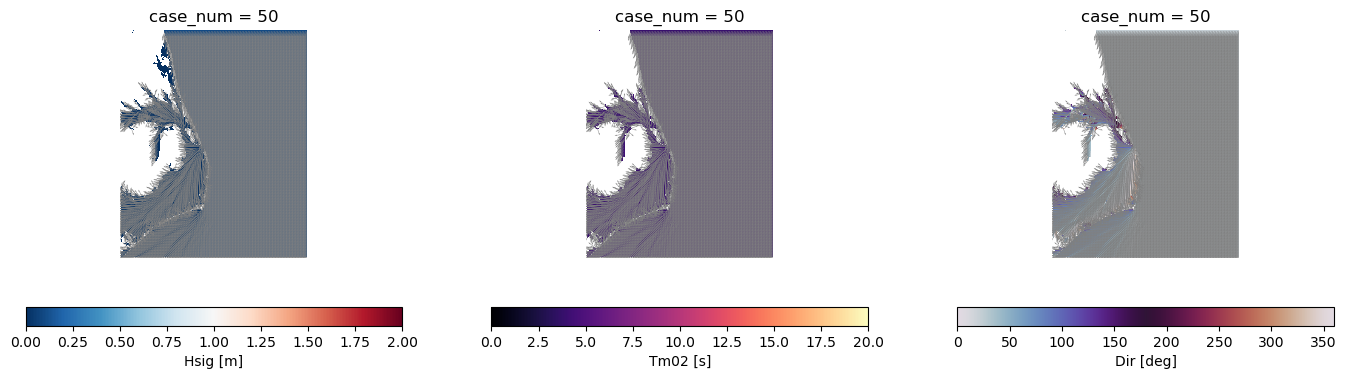

In [30]:
from utils.plotting import plot_case_variables

plot_case_variables(
    data=cases_bulk_parameters.isel(case_num=50),
)

## Plot ALL pre-run cases

"not all values found in index 'case_num'. Try setting the `method` keyword argument (example: method='nearest')."


/home/grupos/geocean/montanoj/miniconda3/envs/calval/lib/python3.13/site-packages/matplotlib/colors.py:2293: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


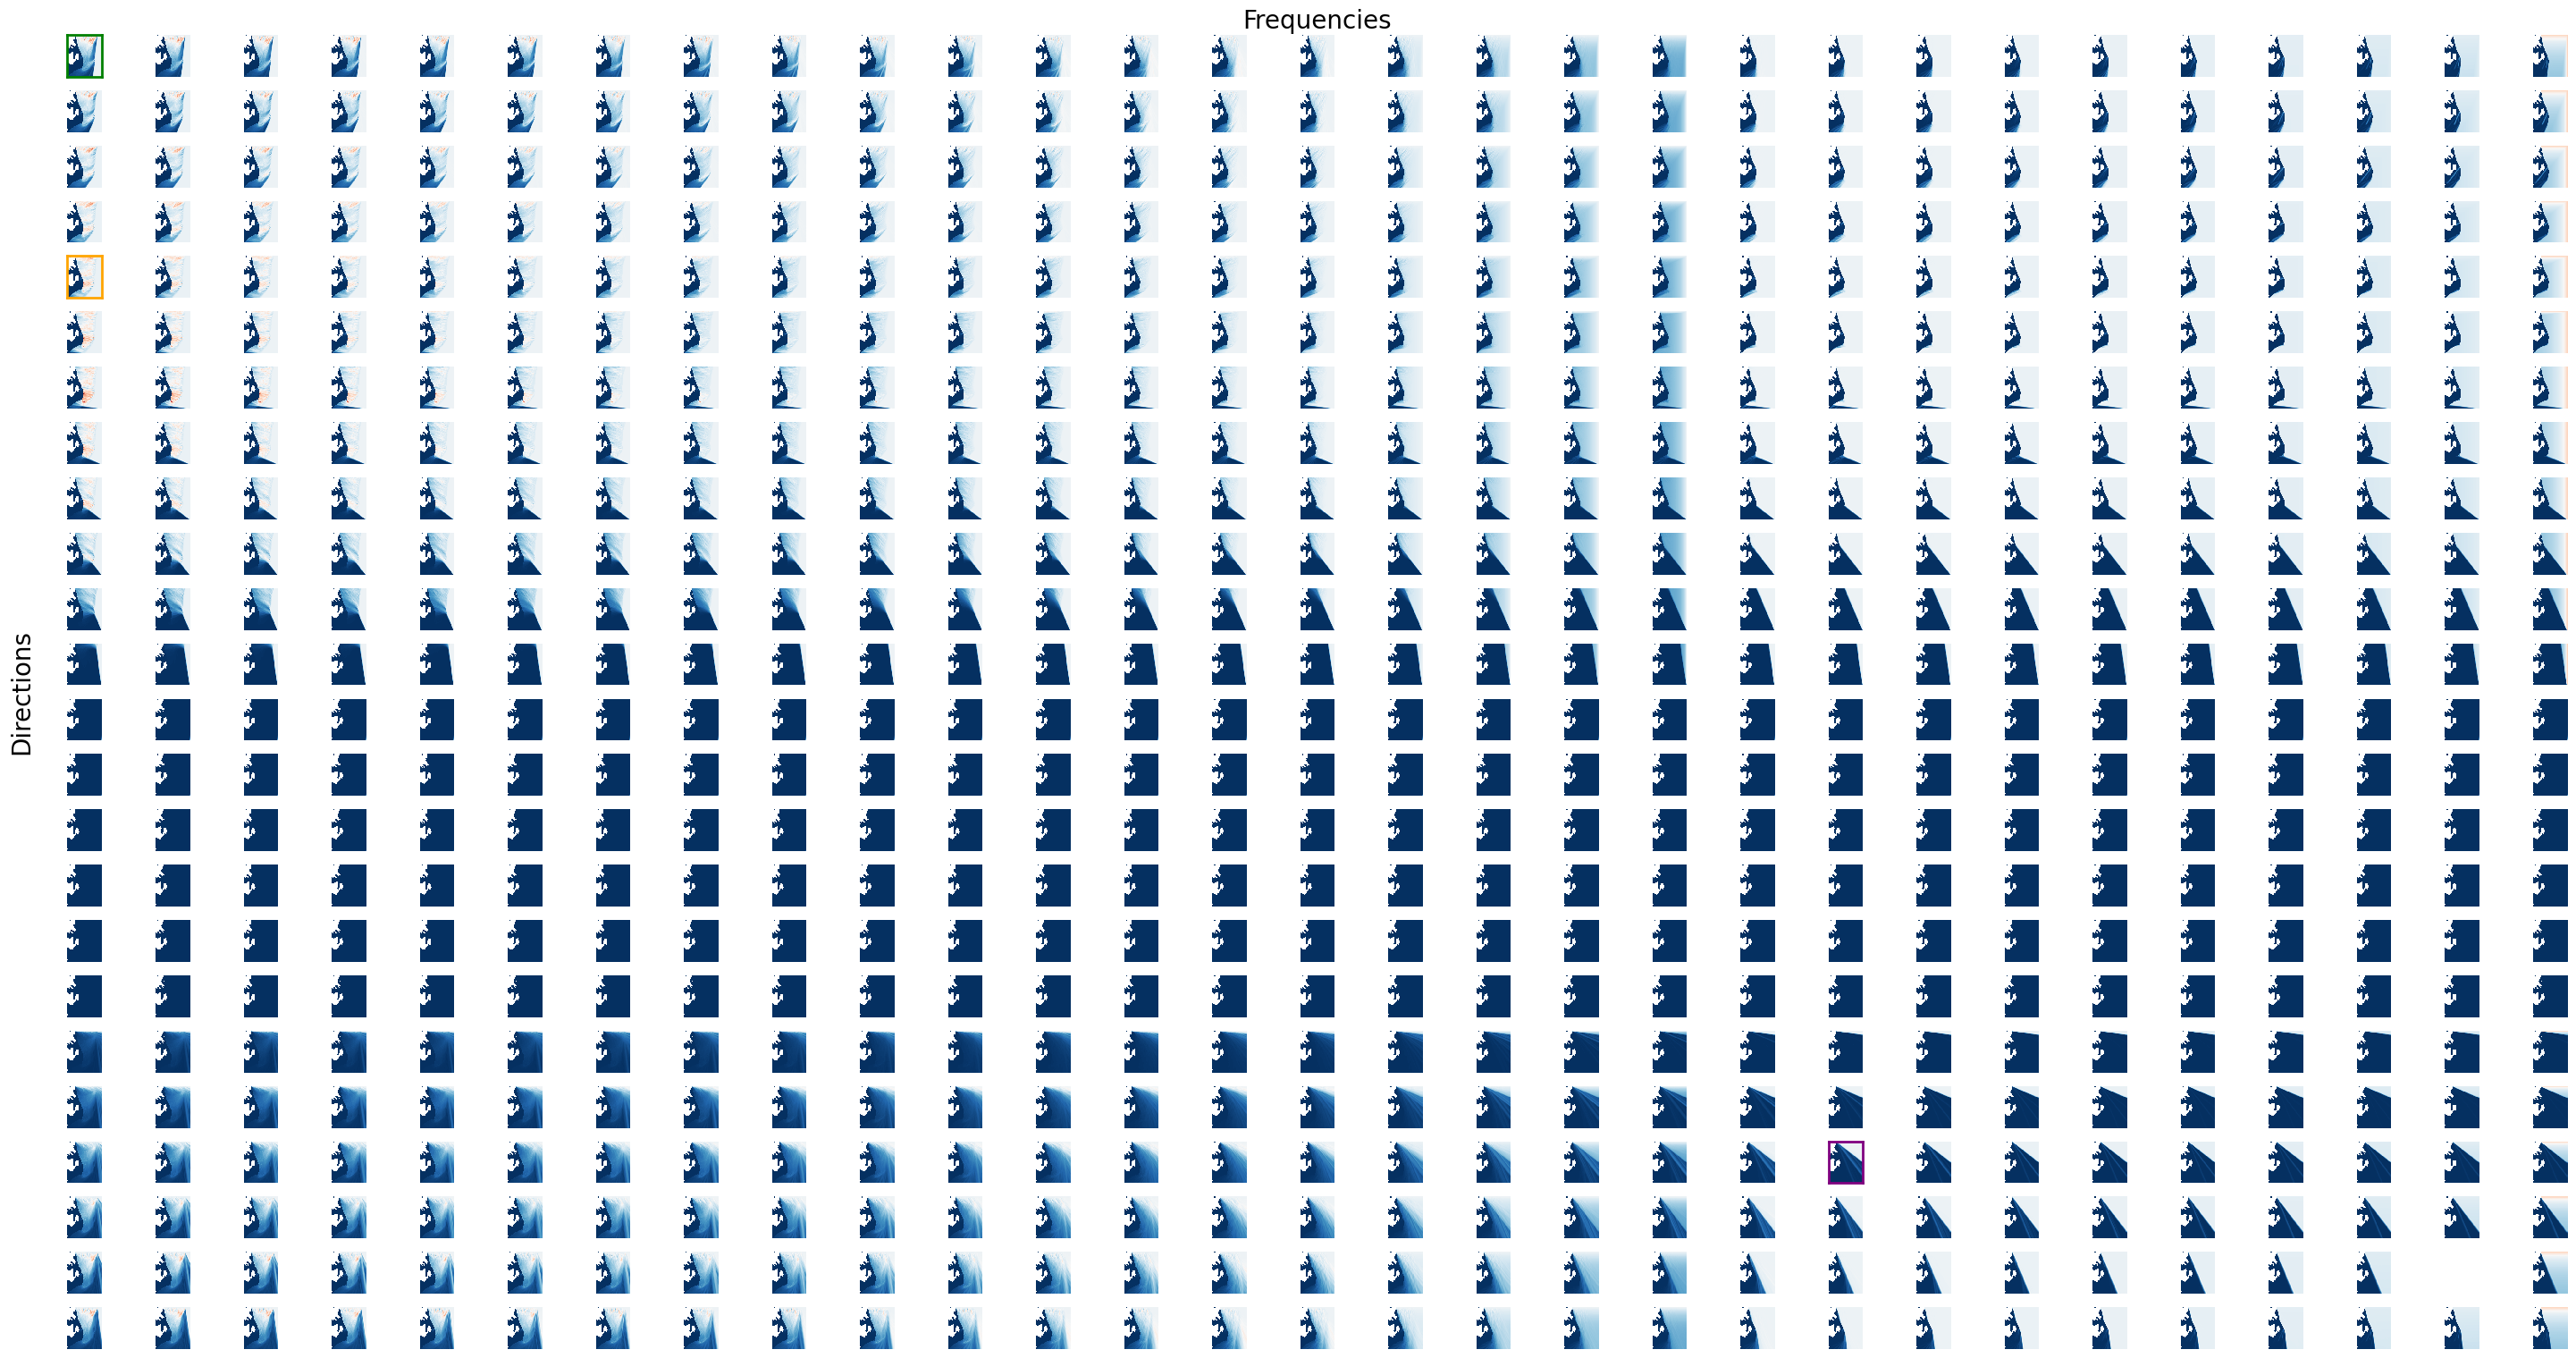

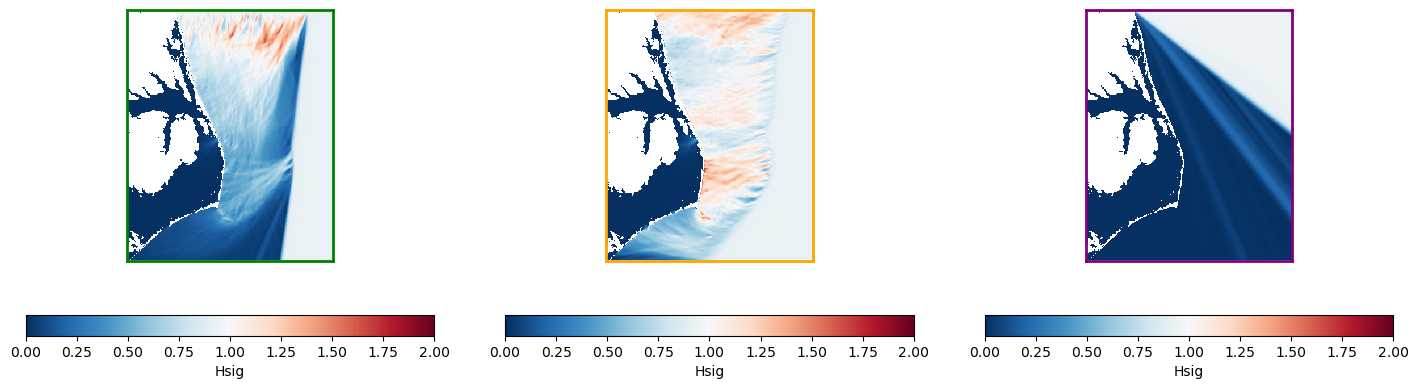

In [31]:
from utils.plotting import plot_cases_grid

plot_cases_grid(
    data=cases_bulk_parameters.Hsig.where(
        cases_bulk_parameters.case_num.isin(
            swan_cases_df.where(swan_cases_df["hs"] == 1.0).dropna().index.values
        ),
        cases_bulk_parameters.Hsig * 10,
    ),
    cases_to_plot=[0, 29*4, 600],
    num_directions=len(example_directions),
    num_frequencies=len(example_frequencies),
)

## Extract kp coefficients

In [13]:
# ps aux | grep python
# pkill -f "python"

In [32]:
from bluemath_tk.waves.binwaves import process_kp_coefficients

list_of_input_spectra = [
    os.path.join(case_dir, "input_spectra_N.bnd")
    for case_dir in swan_wrapper.cases_dirs
]
list_of_output_spectra = [
    os.path.join(case_dir, "output.spec") for case_dir in swan_wrapper.cases_dirs
]

kp_coefficients = process_kp_coefficients(
    list_of_input_spectra=list_of_input_spectra,
    list_of_output_spectra=list_of_output_spectra,
)
kp_coefficients

Error processing /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/Duke2_cases/0665/input_spectra_N.bnd and /lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/Duke2_cases/0665/output.spec
[Errno 2] No such file or directory: '/lustre/geocean/WORK/users/jen/BlueMath/methods/hybrid_downscaling/additive/BinWaves/Duke2_cases/0665/output.spec'


<xarray.DataArray 'efth' (case_num: 695, site: 1672, freq: 31, dir: 24)> Size: 7GB
array([[[[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
...
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 2.60247211e-01]],

        [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [0.00000000e+00, 6.05476188e-10, 0.00000000e+00, ...,
          0.00000000e+00, 4.23833332e-09, 5.99481974e-06]]]],
      shape=(695, 1672, 31, 24))
Coordinates:
  * case_num  (case_num) int64 6kB 0 1 2 3 4 5 6 ... 689 690 691 692 693 694 695
  * site      (site) int64 13kB 1 2 3 4 5 6 7 ... 1667 1668 1669 1670 1671 1672
  * freq      (freq) float64 248B 0.03 0.0329 0.0362 ... 0.4145 0.4552 0.5
  * dir       (dir) float64 192B 7.5 22.5 37.5 52.5 ... 307.5 322.5 337.5 352.5
    time      (case_num) datetime64[ns] 6kB 2025-05-19T20:48:00 ... 2025-05-1...
    lat       float64 8B 0.0
    lon       float64 8B 0.0

In [33]:
# kp_coefficients.to_dataset(name="kps").drop(["time", "lat", "lon"]).assign_coords(
#     utm_x=(("site"), swan_wrapper.locations[:, 0]),
#     utm_y=(("site"), swan_wrapper.locations[:, 1]),
# ).to_netcdf("outputs/kp_coefficients.nc")
# If you only need to drop 'time':
kp_coefficients.to_dataset(name="kps").drop(["time"]).assign_coords(
    utm_x=(("site"), swan_wrapper.locations[:, 0]),
    utm_y=(("site"), swan_wrapper.locations[:, 1]),
).to_netcdf("outputs/kp_coefficients.nc")

/tmp/ipykernel_2915629/4113431545.py:6: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  kp_coefficients.to_dataset(name="kps").drop(["time"]).assign_coords(
